In [1]:
import pandas as pd
import re

df = pd.read_csv('dubai_properties.csv')

df.head()

,Address,Rent,Beds,Baths,Type,Area_in_sqft,Rent_per_sqft,Rent_category,Frequency,Furnishing,Purpose,Posted_date,Age_of_listing_in_days,Location,City,Latitude,Longitude
0,"The Gate Tower 2, The Gate Tower, Shams Gate D...",124000,3,4,Apartment,1785,69.467787,Medium,Yearly,Unfurnished,For Rent,2024-03-07,45,Al Reem Island,Abu Dhabi,24.493598,54.407841
1,"Water's Edge, Yas Island, Abu Dhabi",140000,3,4,Apartment,1422,98.452883,Medium,Yearly,Unfurnished,For Rent,2024-03-08,44,Yas Island,Abu Dhabi,24.494022,54.607372
2,"Al Raha Lofts, Al Raha Beach, Abu Dhabi",99000,2,3,Apartment,1314,75.342466,Medium,Yearly,Furnished,For Rent,2024-03-21,31,Al Raha Beach,Abu Dhabi,24.485931,54.600939
3,"Marina Heights, Marina Square, Al Reem Island,...",220000,3,4,Penthouse,3843,57.246942,High,Yearly,Unfurnished,For Rent,2024-02-24,57,Al Reem Island,Abu Dhabi,24.493598,54.407841
4,"West Yas, Yas Island, Abu Dhabi",350000,5,7,Villa,6860,51.020408,High,Yearly,Unfurnished,For Rent,2024-02-16,65,Yas Island,Abu Dhabi,24.494022,54.607372


In [3]:
# Clear spaces in column names
df.columns = df.columns.str.strip()
# Clear 'Rent' column
df['Rent'] = df['Rent'].astype(str).str.replace(r'[^\d]', '', regex=True)
df['Rent'] = pd.to_numeric(df['Rent'], errors='coerce')
# Clear 'Area_in_sqrt' column
df['Area_in_sqft'] = df['Area_in_sqft'].astype(str).str.replace(r'[^\d]', '', regex=True)
df['Area_in_sqft'] = pd.to_numeric(df['Area_in_sqft'], errors='coerce')

# Convert 'Beds' and 'Baths' columns to numbers (Ex: We can make texts like "Studio" 0 or 0.5)
df['Beds'] = df['Beds'].astype(str).str.lower().replace('studio', '0')
df['Beds'] = df['Beds'].str.extract('(\d+)').astype(float)

# Clear missing (NaN) data The important thing is that there is no empty data in the Rent, Area_in_sqrt and Beds columns.
df = df.dropna(subset=['Rent', 'Area_in_sqft', 'Beds'])

# Filter unnecessary outliers. For example, let's remove data whose rent is 0 or extremely low/high (incorrect entries).
# For Dubai, rents below AED 5,000 or above AED 5,000,000 may distort the analysis
df = df[(df['Rent'] > 5000) & (df['Rent'] < 2000000)]

print("Clear complete")
print(df[['Rent', 'Area_in_sqft', 'Beds']].head())


Clear complete
     Rent  Area_in_sqft  Beds
0  124000          1785   3.0
1  140000          1422   3.0
2   99000          1314   2.0
3  220000          3843   3.0
4  350000          6860   5.0


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score 


In [5]:
X = df[['Area_in_sqft', 'Beds']]
y = df['Rent'] 

# split %80 training, %20 test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create model and training
model = LinearRegression()
model.fit(X_train, y_train)

# Let's make a prediction and measure the model's success (R²).
y_pred = model.predict(X_test)
print(f"Model Successfully Rate (R2 Score): {r2_score(y_test, y_pred):.4f}")

#Let's see the Model Coefficients (Which factor affects the rent and how much?)
print(f"Impact per Square Meter: {model.coef_[0]:.2f} AED")
print(f"Impact per Bedroom: {model.coef_[1]:.2f} AED")      

Model Successfully Rate (R2 Score): 0.2397
Impact per Square Meter: 10.79 AED
Impact per Bedroom: 35121.74 AED


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sns as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


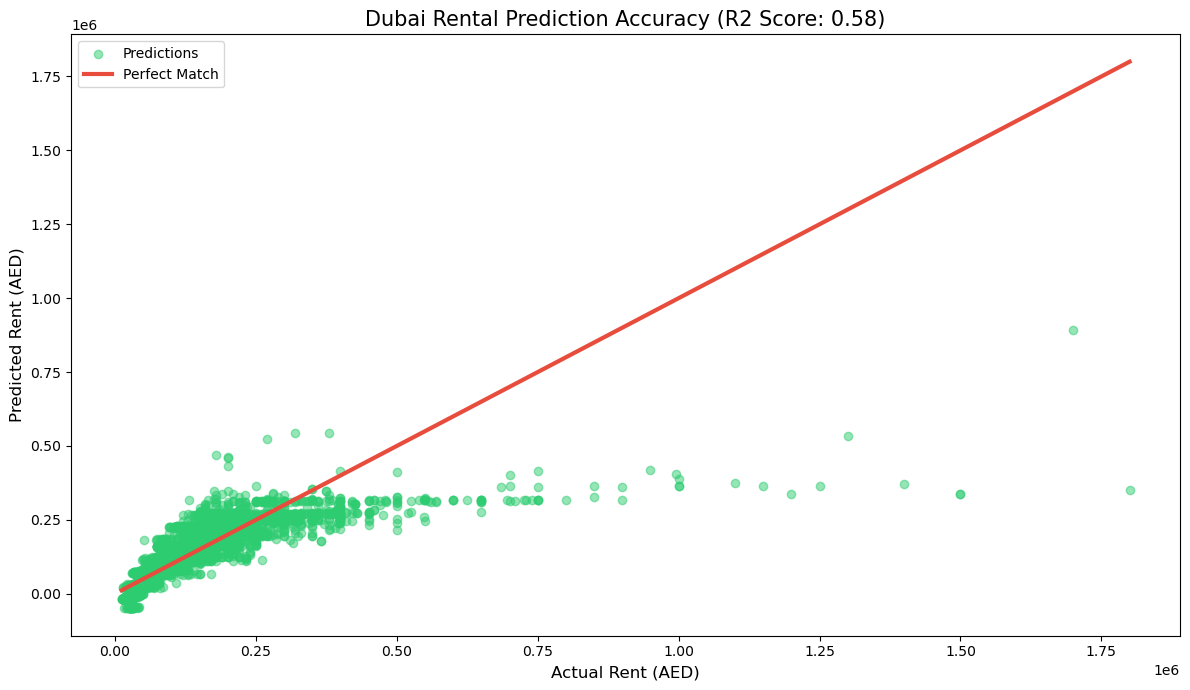

Update Successfully Rate: %58.48


In [15]:
#To improve the success rate, let's convert the "Neighborhood" column to numerical data (Dummy Variables).
# We can strengthen the model without complicating it by only including the 10 most popular regions.
top_locations = df['Location'].value_counts().nlargest(10).index
df_filtered = df[df['Location'].isin(top_locations)].copy()

X = pd.get_dummies(df_filtered[['Area_in_sqft', 'Beds', 'Location']], drop_first=True)
y = df_filtered['Rent']

# Training Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(12, 7))


# Real and Predict points
plt.scatter(y_test, y_pred, alpha=0.5, color='#2ecc71', label='Predictions')

# Ideal Line (If the predictions were perfect, all points would be on this line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='#e74c3c', lw=3, label='Perfect Match')

plt.title(f'Dubai Rental Prediction Accuracy (R2 Score: {r2_score(y_test, y_pred):.2f})', fontsize=15)
plt.xlabel('Actual Rent (AED)', fontsize=12)
plt.ylabel('Predicted Rent (AED)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Update Successfully Rate: %{r2_score(y_test, y_pred)*100:.2f}")
